#### Step 4 :- EDA
###### Input :- We will take the enhanced collision dataset that we made from feature engineering 
###### Processing :- In these one we will see and look at is there any relationship between feature and collision severity
###### Output :- By the end we will get a proper visualization of which factor affects the target column

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = '../Data/enhanced_collision.csv'
df = pd.read_csv(data)
print(df.shape)
print(df.info())
sns.set_style(style='darkgrid')

(503373, 30)
<class 'pandas.DataFrame'>
RangeIndex: 503373 entries, 0 to 503372
Data columns (total 30 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   collision_year              503373 non-null  int64  
 1   longitude                   503373 non-null  float64
 2   latitude                    503373 non-null  float64
 3   collision_severity          503373 non-null  int64  
 4   number_of_vehicles          503373 non-null  int64  
 5   number_of_casualties        503373 non-null  int64  
 6   day_of_week                 503373 non-null  int64  
 7   first_road_class            503373 non-null  int64  
 8   road_type                   503373 non-null  int64  
 9   speed_limit                 503373 non-null  float64
 10  junction_detail             503373 non-null  float64
 11  second_road_class           503373 non-null  float64
 12  pedestrian_crossing         503373 non-null  float64
 13  light_condit

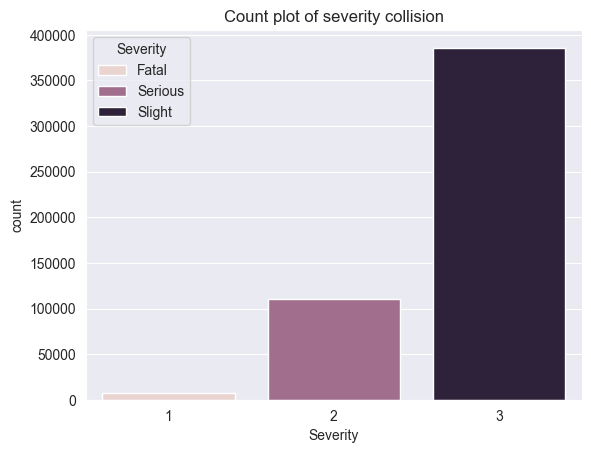

In [9]:
sns.countplot(data=df,x='collision_severity',hue='collision_severity')
plt.title('Count plot of severity collision')
plt.xlabel('Severity')
plt.legend(title = 'Severity',labels = ['Fatal','Serious','Slight'])
plt.show()

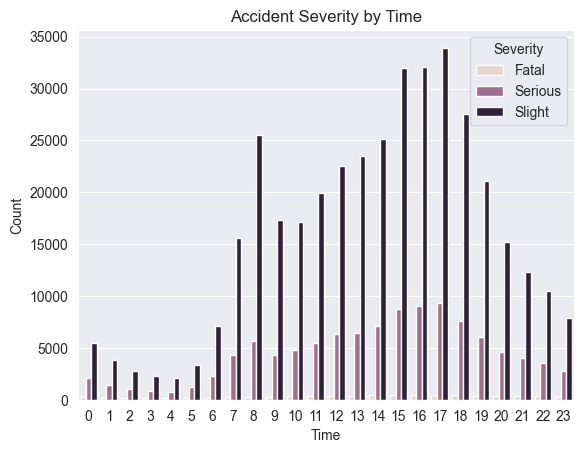

In [4]:
sns.countplot(data=df , x= 'hour', hue = 'collision_severity')
plt.title('Accident Severity by Time')
plt.xlabel('Time')
plt.ylabel('Count')
plt.legend(title = 'Severity',labels = ['Fatal','Serious','Slight'])
plt.savefig('../Output/SeverityByTime.png',dpi=150,bbox_inches='tight')
plt.show()

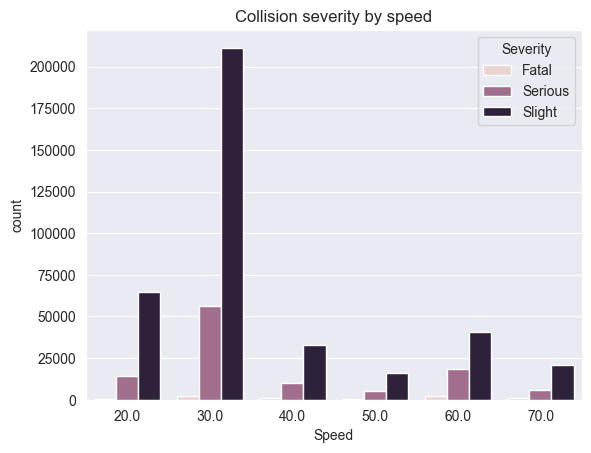

In [5]:
sns.countplot(data=df,x='speed_limit',hue='collision_severity')
plt.title('Collision severity by speed')
plt.xlabel('Speed')
plt.legend(title='Severity',labels=['Fatal','Serious','Slight'])
plt.savefig('../Output/SeverityBySpeed.png',dpi=150,bbox_inches ='tight')

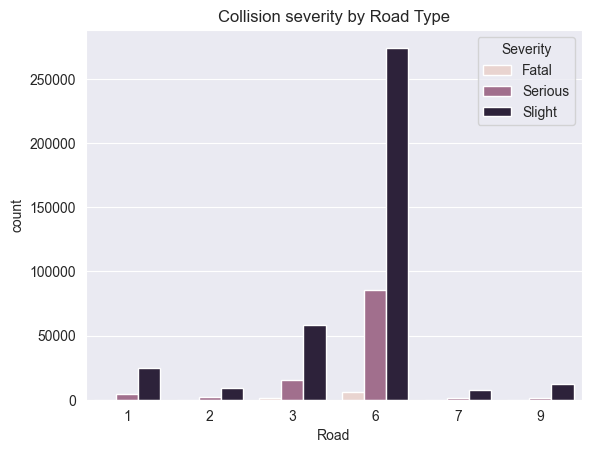

In [6]:
sns.countplot(data=df,x='road_type',hue='collision_severity')
plt.title('Collision severity by Road Type')
plt.xlabel('Road')
plt.legend(title='Severity',labels=['Fatal','Serious','Slight'])
plt.savefig('../Output/SeverityByRoadType.png',dpi=150,bbox_inches ='tight')

##### By doing just One by One its tiring so we gonna use a subplots to all in one 

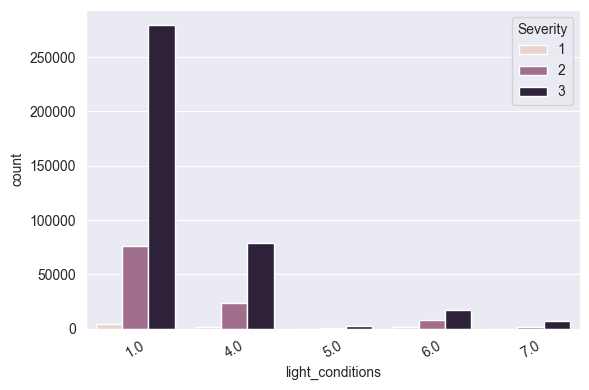

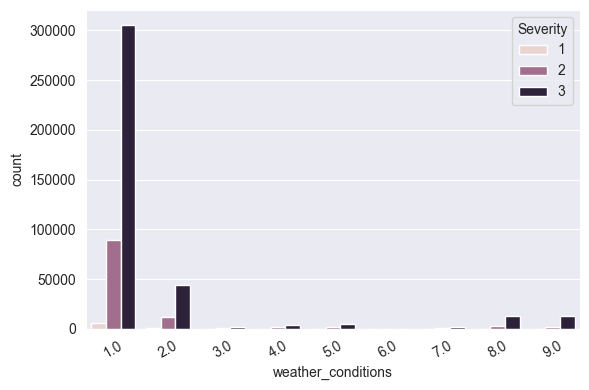

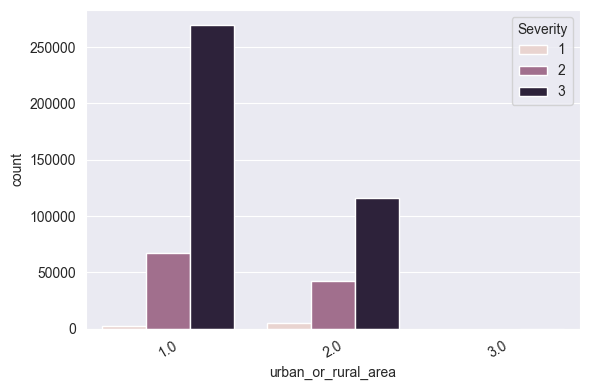

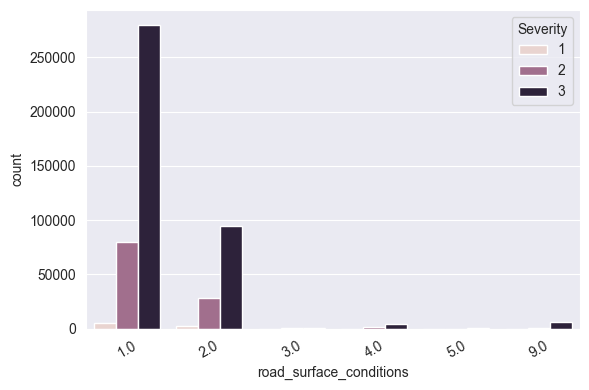

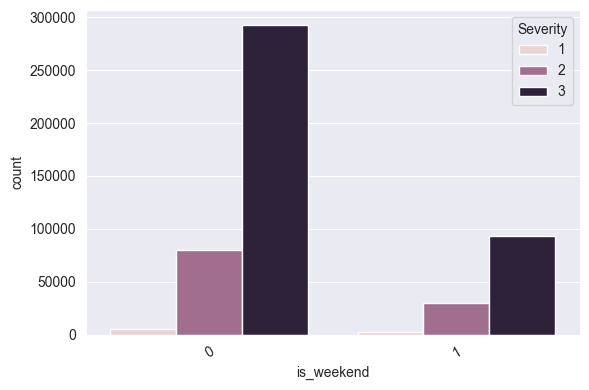

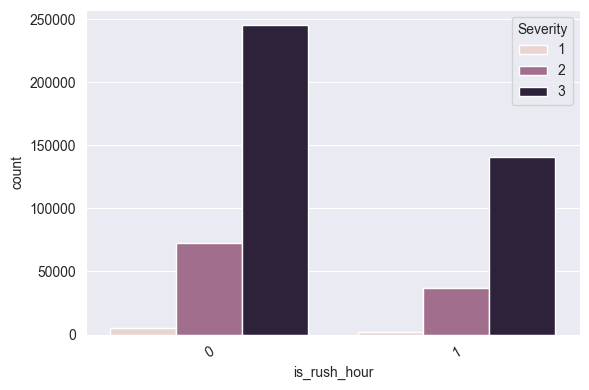

In [7]:
Columns_toPlot = ['light_conditions','weather_conditions','urban_or_rural_area','road_surface_conditions','is_weekend','is_rush_hour']

for cols in Columns_toPlot:
    
    fig, ax = plt.subplots(figsize=(6,4))
    sns.countplot(data=df, x=cols, hue='collision_severity', ax=ax)
    ax.legend(title='Severity')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    fig.savefig(f'../Output/SeverityBy{cols}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)


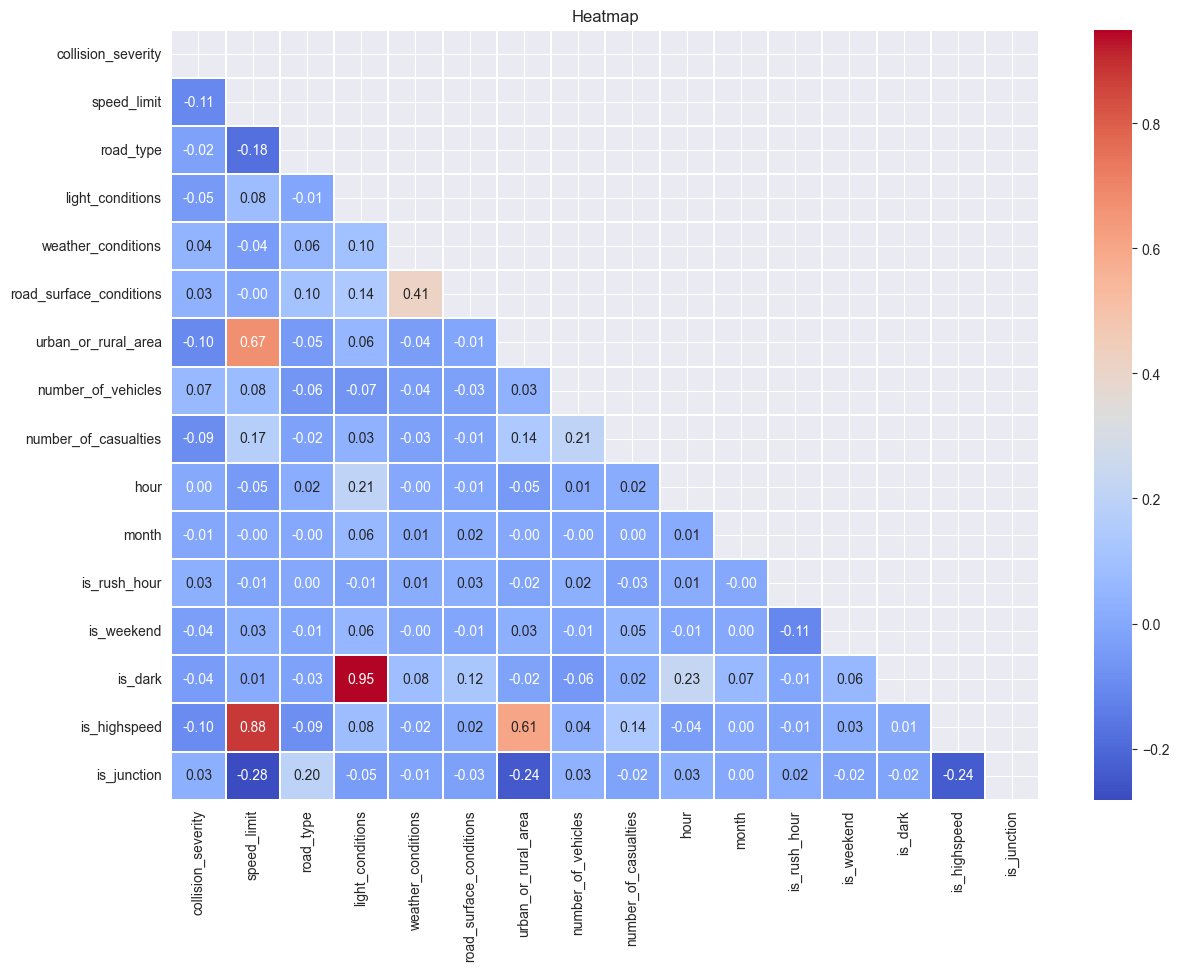

In [31]:
plt.figure(figsize=(14,10))
heatmaps_cols = ['collision_severity', 'speed_limit', 'road_type', 'light_conditions',
    'weather_conditions', 'road_surface_conditions', 'urban_or_rural_area',
    'number_of_vehicles', 'number_of_casualties', 'hour', 'month',
    'is_rush_hour', 'is_weekend', 'is_dark', 'is_highspeed', 'is_junction']
corr = df[heatmaps_cols].corr()
heat_mask=np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.01,mask=heat_mask)
plt.title('Heatmap')
plt.savefig('../Output/OverallHeatmap.png',dpi=150,bbox_inches='tight')
plt.show()

In [32]:
corr_with_target = df[heatmaps_cols].corr()['collision_severity'].sort_values()
print(corr_with_target)

speed_limit               -0.105027
urban_or_rural_area       -0.101705
is_highspeed              -0.097715
number_of_casualties      -0.090682
light_conditions          -0.050000
is_dark                   -0.042931
is_weekend                -0.035452
road_type                 -0.024433
month                     -0.006337
hour                       0.002828
is_junction                0.026517
is_rush_hour               0.030251
road_surface_conditions    0.032004
weather_conditions         0.041299
number_of_vehicles         0.066980
collision_severity         1.000000
Name: collision_severity, dtype: float64


##### Key Findings:-
##### So what we really found that the columns varies or has correlationship with each other on some way example like on speed limit fatal rate is more higher on 60-70 range of speed .LikeWise same with other column every column is channging with its value on junction on the 4 there is more fatal and more accident there are tons of relation which is the real motive of EDA 